In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

import concurrent.futures


import numpy as np
import pandas as pd
import ast
import glob
import pickle
import dask
import os
import itertools

import pickle

#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm

from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
#from tqdm import tqdm
from collections import Counter
from functools import reduce


import dask
import dask.dataframe as dd
from dask.distributed import Client
from dask.diagnostics import ProgressBar

#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

### Load TLGRF Benchmark Dataset

In [2]:
benchmark_TLGRF_dataset = dd.read_csv("../generate_benchmark_TLGRF_dataset/benchmark_TLGRF_dataset.csv", assume_missing=True).compute()
benchmark_TLGRF_dataset["date"] = pd.to_datetime(benchmark_TLGRF_dataset["date"])
benchmark_TLGRF_dataset = benchmark_TLGRF_dataset[benchmark_TLGRF_dataset["log_rolled_cases"] >= np.log(21.1)]
benchmark_TLGRF_dataset = benchmark_TLGRF_dataset[benchmark_TLGRF_dataset["date"] <= "2022-12-31"]
benchmark_TLGRF_dataset = benchmark_TLGRF_dataset.sort_values(by=["fips","date"])
display(benchmark_TLGRF_dataset)

,fips,days_from_start,intercept_TLGRF,r_TLGRF,county,state,date,rolled_cases,log_rolled_cases,shifted_log_rolled_cases,TLGRF_predicted_log_rolled_cases
17,1001.0,86.0,NaN,NaN,Autauga,Alabama,2020-04-16,20.285714,3.062723,3.133629,NaN
18,1001.0,87.0,-26.766326,0.028066,Autauga,Alabama,2020-04-17,20.714286,3.082565,3.170286,3.279026
19,1001.0,88.0,-313.778047,0.007752,Autauga,Alabama,2020-04-18,20.714286,3.082565,3.205646,3.136830
20,1001.0,89.0,-60.990643,0.021119,Autauga,Alabama,2020-04-19,21.000000,3.095578,3.228543,3.243410
21,1001.0,90.0,-54.020959,0.022045,Autauga,Alabama,2020-04-20,21.428571,3.114784,3.256447,3.269100
...,...,...,...,...,...,...,...,...,...,...,...
10119,99999.0,1071.0,2837.736966,-0.006383,New York City,New York,2022-12-27,81539.428571,11.308855,11.249207,11.264175
10120,99999.0,1072.0,2628.429057,-0.007237,New York City,New York,2022-12-28,80849.571429,11.300359,11.241229,11.249699
10121,99999.0,1073.0,2338.714337,-0.008885,New York City,New York,2022-12-29,80031.285714,11.290187,11.234906,11.227992
10122,99999.0,1074.0,2540.040095,-0.007669,New York City,New York,2022-12-30,79315.142857,11.281198,11.229165,11.227516


In [3]:
TLGRF_MAE = benchmark_TLGRF_dataset.groupby("date").apply(lambda x: np.nanmean(abs(x["TLGRF_predicted_log_rolled_cases"]- x["shifted_log_rolled_cases"])))
TLGRF_RMSE = benchmark_TLGRF_dataset.groupby("date").apply(lambda x: np.sqrt(np.nanmean( (x["TLGRF_predicted_log_rolled_cases"]- x["shifted_log_rolled_cases"])**2 )))


/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: RuntimeWarning: Mean of empty slice
  """Entry point for launching an IPython kernel.
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: Mean of empty slice
  


In [4]:
TLGRF_MAE

date
2020-03-06         NaN
2020-03-07         NaN
2020-03-08         NaN
2020-03-09         NaN
2020-03-10         NaN
                ...   
2022-12-27    0.199477
2022-12-28    0.130100
2022-12-29    0.112732
2022-12-30    0.112997
2022-12-31    0.115126
Length: 1031, dtype: float64

### Load Augmented DF Benchmark Dataset

In [5]:
augmented_df = dd.read_csv("../../data/augmented_us-counties_latest.csv", assume_missing=True).compute()
augmented_df["date"] = pd.to_datetime(augmented_df["date"])
augmented_df["fips"] = augmented_df["fips"].astype(int)
augmented_df["days_from_start"] = augmented_df["days_from_start"].astype(int)
augmented_df["log_rolled_cases"] = np.log(augmented_df["rolled_cases"] + 1.1)
augmented_df = augmented_df.sort_values(by=["fips","date"])
augmented_df["shifted_log_rolled_cases"] = augmented_df.groupby("fips")["log_rolled_cases"].shift(-7)

# Check for gaps
gt_columns = ["fips", "days_from_start", "date", "log_rolled_cases", "shifted_log_rolled_cases"]
augmented_df_gt = augmented_df[gt_columns]
grouped = augmented_df_gt.groupby('fips')

for fips, group in grouped:
    missing_days = group['days_from_start'].diff().gt(1).sum()
    if missing_days > 0:
        print(f"Gap(s) found in 'days_from_start' for fips {fips}: {missing_days} gap(s)")


#df = augmented_df.copy()
window_sizes = list(range(2,15))
fips_list = augmented_df_gt["fips"].unique()

/home/zwang937/anaconda3/lib/python3.7/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Load Benchmark Data of $wsize \in \{2,3,4,\dotsc,13,14\}$

In [6]:
directory = "Fixed_Window_dfs"
file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
def read_csv(file_path):
    return pd.read_csv(file_path)
with tqdm(total=len(file_paths), desc="Processing") as pbar:
    beta_results = Parallel(n_jobs=-1)(delayed(read_csv)(file_path) for file_path in file_paths)

### Check for Duplicates

In [7]:
present_fips_wsize_dict = {}
for fname in file_paths:
    fips = int(float(fname.split("=")[1].split("_")[0]))
    window_size = int(float(fname.split("=")[2].split(".")[0]))
    if fips not in present_fips_wsize_dict.keys():
        present_fips_wsize_dict[fips] = Counter()
    if window_size in present_fips_wsize_dict[fips].keys():
        print("Duplicate detected fips={} window_size={}".format(fips, window_size))
        present_fips_wsize_dict[fips][window_size] += 1
    else:
        present_fips_wsize_dict[fips].update({window_size : 1})

### Remove fips with too few entries

In [8]:
sorted_beta_results = sorted(beta_results, key = lambda x: (x["fips"].unique()[0], x.columns[2] ))

beta_result_dict_wsize_fips = {}
for beta_df in tqdm(sorted_beta_results):
    fips = int(beta_df["fips"].unique()[0])
    window_size = int(beta_df.columns[2].split("=")[1])
    if fips not in beta_result_dict_wsize_fips.keys():
        beta_result_dict_wsize_fips[fips] = {window_size:beta_df}
    else:
        beta_result_dict_wsize_fips[fips][window_size] = beta_df
        

counter = 0
problematic_fips = {}
for fips in tqdm(beta_result_dict_wsize_fips.keys()):
    counter += 1
    expected_shape = list(beta_result_dict_wsize_fips[fips].items())[0][1].shape
    #print("fips={} has expected shape {}".format(fips, expected_shape))
    have_windows = set(beta_result_dict_wsize_fips[fips].keys())
    missing_window_sizes = set(window_sizes) - set(have_windows)
    if len(missing_window_sizes):
        print("fips={} has missing window_sizes of {}".format(fips, missing_window_sizes))
        problematic_fips[fips] = missing_window_sizes
    for window_size in beta_result_dict_wsize_fips[fips].keys():
        current_shape = beta_result_dict_wsize_fips[fips][window_size].shape
        if current_shape != expected_shape:
            print("fips={}, wsize={} has shape {}, differing from expected {}".format(fips, window_size, expected_shape, current_shape))
        
print(len(fips_list) - counter)


0


In [9]:
beta_result_dict_wsize_fips[1001]

{10:       fips  days_from_start  beta_wsize=10
 0     1001               69            NaN
 1     1001               70            NaN
 2     1001               71            NaN
 3     1001               72            NaN
 4     1001               73            NaN
 ...    ...              ...            ...
 1084  1001             1153      -0.045053
 1085  1001             1154      -0.049459
 1086  1001             1155      -0.053846
 1087  1001             1156      -0.057612
 1088  1001             1157      -0.058405
 
 [1089 rows x 3 columns],
 11:       fips  days_from_start  beta_wsize=11
 0     1001               69            NaN
 1     1001               70            NaN
 2     1001               71            NaN
 3     1001               72            NaN
 4     1001               73            NaN
 ...    ...              ...            ...
 1084  1001             1153      -0.042921
 1085  1001             1154      -0.047085
 1086  1001             1155      -0.051

### Merge Results

In [10]:
beta_result_dict = {window_size:[] for window_size in window_sizes}
for beta_df in tqdm(sorted_beta_results):
    fips = int(beta_df["fips"].unique()[0])
    window_size = int(beta_df.columns[2].split("=")[1])
    if fips not in problematic_fips.keys() and window_size in window_sizes:
        beta_result_dict[window_size].append(beta_df)

concatenated_beta_result_dict = {}
for window_size, beta_df_list in tqdm(beta_result_dict.items()):
    concatenated_beta_result_dict[window_size] = pd.concat(beta_df_list)
#updated_df.to_csv("TLGRF_w_Fixed_Windows.csv", index=False)

In [11]:
concatenated_beta_result_dict

{2:        fips  days_from_start  beta_wsize=2
 0      1001               69           NaN
 1      1001               70      0.128657
 2      1001               71      0.113975
 3      1001               72      0.069352
 4      1001               73      0.095767
 ...     ...              ...           ...
 1107  99999             1153     -0.033310
 1108  99999             1154     -0.047988
 1109  99999             1155     -0.066658
 1110  99999             1156     -0.024689
 1111  99999             1157     -0.030971
 
 [3390316 rows x 3 columns],
 3:        fips  days_from_start  beta_wsize=3
 0      1001               69           NaN
 1      1001               70           NaN
 2      1001               71      0.121316
 3      1001               72      0.091664
 4      1001               73      0.082559
 ...     ...              ...           ...
 1107  99999             1153     -0.032773
 1108  99999             1154     -0.040649
 1109  99999             1155     -0.05

In [12]:
beta_df_big = pd.DataFrame()
#for window_size, fips_beta_df in tqdm(concatenated_beta_result_dict.items()):
#    if not beta_df_big.shape[0]:
#        beta_df_big = fips_beta_df.copy()
#        continue
#    beta_df_big = pd.merge(beta_df_big, fips_beta_df, on="fips", how="outer")

beta_df_big = reduce(lambda left, right: pd.merge(left, right, on=['fips','days_from_start'], how='outer'), concatenated_beta_result_dict.values())


updated_df = pd.merge(augmented_df_gt, beta_df_big,on=['fips','days_from_start'], how="outer").sort_values(by=["fips", 'days_from_start'])
filtered_updated_df = updated_df[updated_df["date"] <= "2022-12-31"]
#filtered_updated_df = pd.merge(filtered_updated_df, augmented_df_gt, on=["fips","days_from_start"], how="left")

display(filtered_updated_df)

,fips,days_from_start,date,log_rolled_cases,shifted_log_rolled_cases,beta_wsize=2,beta_wsize=3,beta_wsize=4,beta_wsize=5,beta_wsize=6,beta_wsize=7,beta_wsize=8,beta_wsize=9,beta_wsize=10,beta_wsize=11,beta_wsize=12,beta_wsize=13,beta_wsize=14
0,1001,69,2020-03-30,1.831438,2.469309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1001,70,2020-03-31,1.960095,2.528012,0.128657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1001,71,2020-04-01,2.074070,2.550561,0.113975,0.121316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1001,72,2020-04-02,2.143422,2.625703,0.069352,0.091664,0.104993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1001,73,2020-04-03,2.239189,2.676117,0.095767,0.082559,0.090663,0.099883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3390229,99999,1071,2022-12-27,11.308855,11.249207,-0.008241,-0.017257,-0.014903,-0.012724,-0.009987,-0.006620,-0.003349,-0.000257,0.002930,0.005889,0.008552,0.010720,0.012296
3390230,99999,1072,2022-12-28,11.300359,11.241229,-0.008496,-0.008368,-0.013727,-0.013334,-0.012226,-0.010298,-0.007610,-0.004795,-0.002002,0.000944,0.003754,0.006341,0.008515
3390231,99999,1073,2022-12-29,11.290187,11.234906,-0.010173,-0.009334,-0.008922,-0.012310,-0.012435,-0.011828,-0.010417,-0.008243,-0.005825,-0.003326,-0.000629,0.002004,0.004480
3390232,99999,1074,2022-12-30,11.281198,11.229165,-0.008988,-0.009580,-0.009314,-0.009046,-0.011431,-0.011744,-0.011426,-0.010377,-0.008606,-0.006530,-0.004307,-0.001855,0.000590


In [13]:
predictor_columns = ["beta_wsize={}".format(window_size) for window_size in window_sizes]

In [14]:
MAE_df = pd.DataFrame()
RMSE_df = pd.DataFrame()
MAE_df["r_TLGRF"] = TLGRF_MAE
RMSE_df["r_TLGRF"] = TLGRF_RMSE
for predictor_column in tqdm(predictor_columns):
    predictor_MAE = filtered_updated_df.groupby("date").apply(lambda x: np.nanmean(abs(x[predictor_column]*7+x["log_rolled_cases"]- x["shifted_log_rolled_cases"])))
    predictor_RMSE = filtered_updated_df.groupby("date").apply(lambda x: np.sqrt(np.nanmean( (x[predictor_column]*7+x["log_rolled_cases"] - x["shifted_log_rolled_cases"])**2 )))
    MAE_df[predictor_column] = predictor_MAE
    RMSE_df[predictor_column] = predictor_RMSE

/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: Mean of empty slice
  
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:7: RuntimeWarning: Mean of empty slice
  import sys
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: Mean of empty slice
  
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:7: RuntimeWarning: Mean of empty slice
  import sys
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: Mean of empty slice
  
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:7: RuntimeWarning: Mean of empty slice
  import sys
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: Mean of empty slice
  
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:7: RuntimeWarning: Mean of empty slice
  import sys
/home/zwang937/anaconda3

In [15]:
MAE_df

,r_TLGRF,beta_wsize=2,beta_wsize=3,beta_wsize=4,beta_wsize=5,beta_wsize=6,beta_wsize=7,beta_wsize=8,beta_wsize=9,beta_wsize=10,beta_wsize=11,beta_wsize=12,beta_wsize=13,beta_wsize=14
date,,,,,,,,,,,,,,
2020-03-06,NaN,0.440284,0.548242,0.619951,0.666373,0.636595,0.651072,0.660460,0.702494,0.761174,0.873024,0.947707,1.011544,1.152549
2020-03-07,NaN,0.545718,0.508424,0.584207,0.648382,0.712112,0.684855,0.731640,0.711734,0.718685,0.752173,0.847988,0.895872,0.962352
2020-03-08,NaN,0.620630,0.606371,0.597844,0.637238,0.695506,0.768087,0.745473,0.814462,0.803339,0.791974,0.776256,0.869687,0.911069
2020-03-09,NaN,0.563316,0.592534,0.636426,0.639008,0.681533,0.687246,0.767629,0.738509,0.825191,0.830495,0.831667,0.808925,0.866532
2020-03-10,NaN,0.553548,0.612469,0.649432,0.674841,0.690311,0.735090,0.741029,0.803234,0.729041,0.828087,0.839936,0.846539,0.830193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-27,0.199477,0.215671,0.217341,0.219187,0.221536,0.223269,0.226041,0.234552,0.239468,0.242945,0.246669,0.251323,0.255816,0.259212
2022-12-28,0.130100,0.158402,0.180017,0.190156,0.200381,0.207892,0.213209,0.217549,0.221577,0.225861,0.229670,0.233293,0.237766,0.242194
2022-12-29,0.112732,0.132604,0.149702,0.161083,0.167679,0.177777,0.187348,0.195040,0.201292,0.206410,0.208627,0.210777,0.214761,0.219351


In [16]:
RMSE_df

,r_TLGRF,beta_wsize=2,beta_wsize=3,beta_wsize=4,beta_wsize=5,beta_wsize=6,beta_wsize=7,beta_wsize=8,beta_wsize=9,beta_wsize=10,beta_wsize=11,beta_wsize=12,beta_wsize=13,beta_wsize=14
date,,,,,,,,,,,,,,
2020-03-06,NaN,0.609579,0.746632,0.849409,0.869854,0.863366,0.915190,0.936958,0.967226,1.035789,1.126130,1.174471,1.220783,1.317595
2020-03-07,NaN,0.717856,0.694678,0.782682,0.861243,0.908666,0.894140,0.945901,0.955483,0.973712,1.013345,1.092949,1.134346,1.175868
2020-03-08,NaN,0.903811,0.883895,0.873670,0.932765,0.972270,1.032470,1.007858,1.065588,1.064925,1.071609,1.083446,1.152981,1.184108
2020-03-09,NaN,0.918623,0.881883,0.949344,0.960659,1.021270,1.048796,1.126496,1.088738,1.154109,1.150644,1.152363,1.165428,1.227266
2020-03-10,NaN,0.834146,0.903316,0.939512,0.989656,1.012284,1.068897,1.088157,1.174408,1.119687,1.191695,1.189061,1.189737,1.202769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-27,0.263357,0.330959,0.332188,0.337028,0.342032,0.347394,0.355080,0.364394,0.365607,0.364084,0.363394,0.364704,0.367162,0.369491
2022-12-28,0.181111,0.254723,0.270539,0.280412,0.291914,0.301883,0.310211,0.318755,0.327833,0.330122,0.329550,0.329282,0.330536,0.332901
2022-12-29,0.174124,0.240806,0.246507,0.252881,0.255676,0.264068,0.273524,0.281927,0.289940,0.298283,0.301335,0.301714,0.302086,0.303593


In [18]:
metrics_comparison_df = pd.DataFrame()

row_names = ["TLGRF"] + ["Fixed Window {}".format(window_size) for window_size in window_sizes]

metrics_comparison_df["MAE"] = MAE_df.median()
metrics_comparison_df["RMSE"] = RMSE_df.median()
metrics_comparison_df.index = row_names
metrics_comparison_df = metrics_comparison_df[::-1]
metrics_comparison_df

,MAE,RMSE
Fixed Window 14,0.239571,0.373409
Fixed Window 13,0.236506,0.372249
Fixed Window 12,0.233919,0.370985
Fixed Window 11,0.231018,0.370864
Fixed Window 10,0.228107,0.370185
Fixed Window 9,0.224462,0.369265
Fixed Window 8,0.220137,0.367783
Fixed Window 7,0.213482,0.364968
Fixed Window 6,0.207550,0.360429
Fixed Window 5,0.199554,0.354074


In [19]:
latex_table = metrics_comparison_df.to_latex(column_format='c'*len(metrics_comparison_df.columns), float_format='%.3f', escape=False)
print(latex_table)

\begin{tabular}{cc}
\toprule
{} &   MAE &  RMSE \\
\midrule
Fixed Window 14 & 0.240 & 0.373 \\
Fixed Window 13 & 0.237 & 0.372 \\
Fixed Window 12 & 0.234 & 0.371 \\
Fixed Window 11 & 0.231 & 0.371 \\
Fixed Window 10 & 0.228 & 0.370 \\
Fixed Window 9  & 0.224 & 0.369 \\
Fixed Window 8  & 0.220 & 0.368 \\
Fixed Window 7  & 0.213 & 0.365 \\
Fixed Window 6  & 0.208 & 0.360 \\
Fixed Window 5  & 0.200 & 0.354 \\
Fixed Window 4  & 0.191 & 0.350 \\
Fixed Window 3  & 0.182 & 0.343 \\
Fixed Window 2  & 0.175 & 0.339 \\
TLGRF           & 0.127 & 0.195 \\
\bottomrule
\end{tabular}



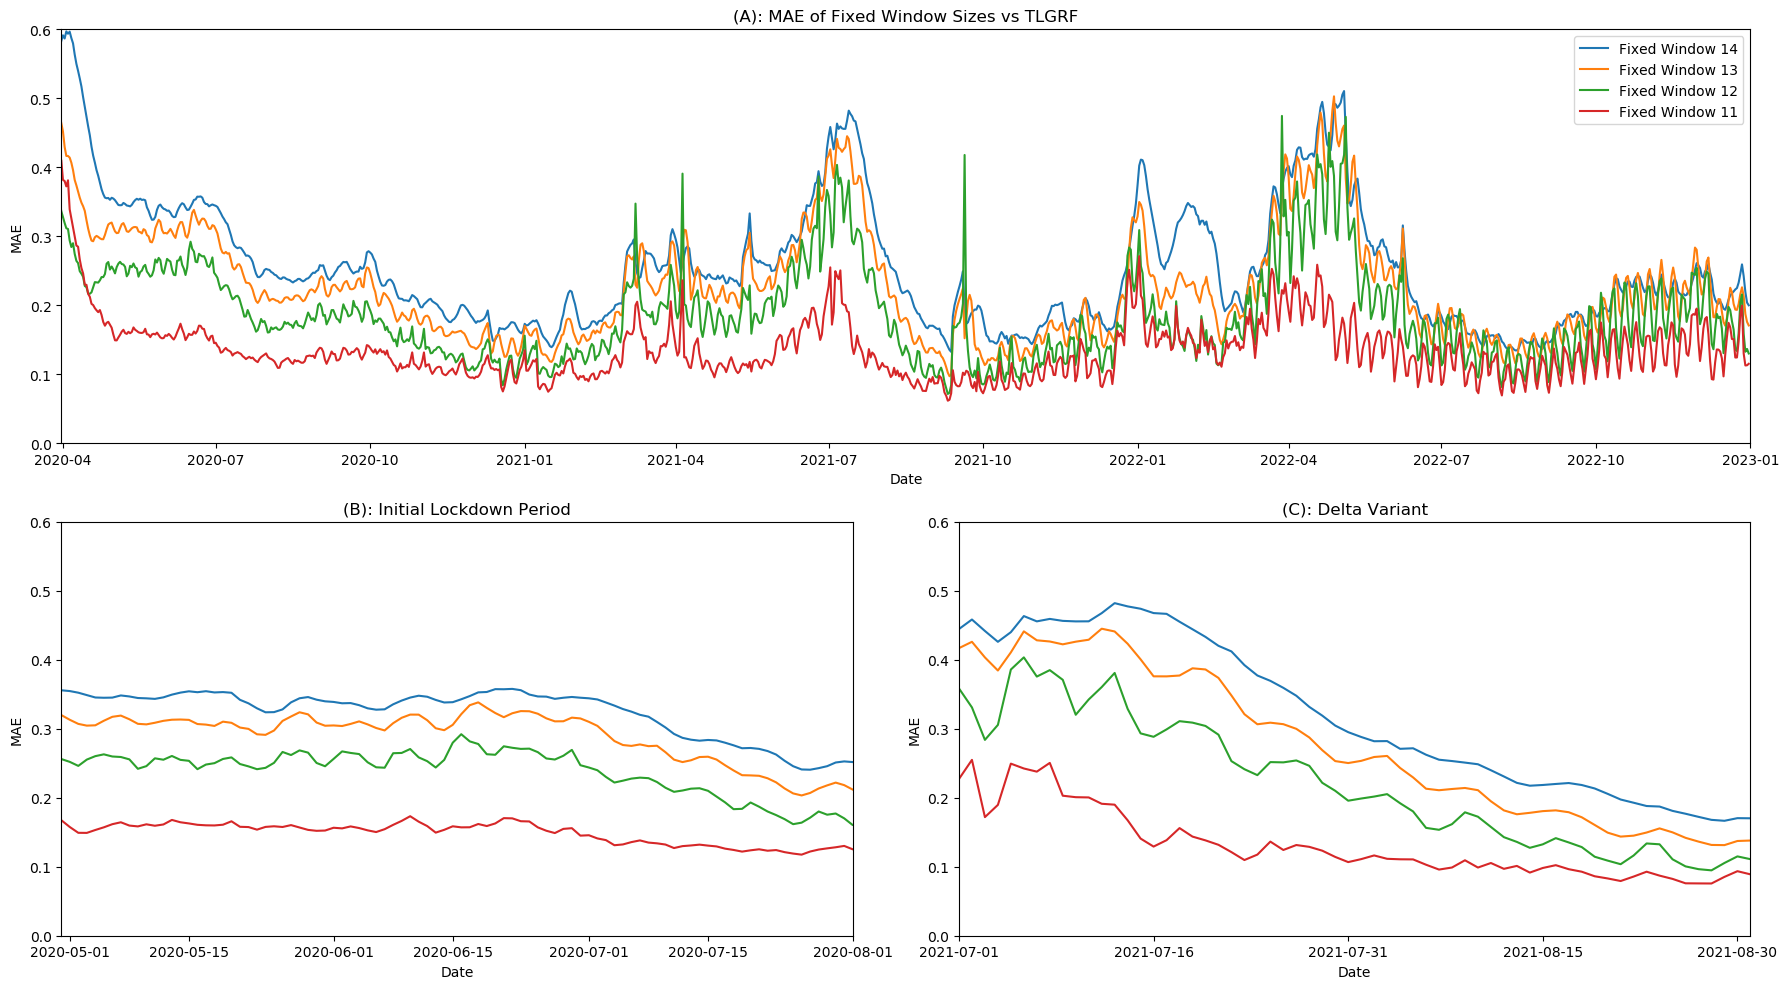

In [20]:
fig = plt.figure(figsize=(18,10))

ax1 = fig.add_subplot(2, 1, 1)
# Create the bottom left subplot
ax2 = fig.add_subplot(2, 2, 3)
# Create the bottom right subplot
ax3 = fig.add_subplot(2, 2, 4)

# Adjust the spacing between subplots
#fig.subplots_adjust(hspace=0.3)

plot_columns =  ["r_TLGRF"] + ["beta_wsize={}".format(window_size) for window_size in [2,7,14]]
plot_columns = reversed(plot_columns)

plot_row_names = list(reversed(row_names))

#plot_columns =  ["r_TLGRF"] + ["beta_wsize={}".format(window_size) for window_size in [2]]
ax1_line_handles = []
for i,plot_column in tqdm(enumerate((plot_columns))):
    ax1_line_handles.append(ax1.plot(MAE_df[plot_column], label=plot_row_names[i]))
    ax2.plot(MAE_df[plot_column], label=plot_row_names[i])
    ax3.plot(MAE_df[plot_column], label=plot_row_names[i])
    
handles = [handle[0] for handle in ax1_line_handles]
labels = [handle[0].get_label() for handle in ax1_line_handles]
locator = mdates.DayLocator(interval=15)
formatter = mdates.DateFormatter('%Y-%m-%d')



ax1.set_xlabel("Date")
ax1.set_ylabel("MAE")
ax1.set_title("(A): MAE of Fixed Window Sizes vs TLGRF")
ax1.set_xlim(pd.to_datetime("2020-03-31"), pd.to_datetime("2023-01-01"))
ax1.set_ylim(0,0.6)
ax1.legend(handles, labels, loc='upper right')

ax2.set_xlabel("Date")
ax2.set_ylabel("MAE")
ax2.set_title("(B): Initial Lockdown Period")
ax2.set_xlim(pd.to_datetime("2020-04-30"), pd.to_datetime("2020-08-01"))
ax2.set_ylim(0,0.6)
#ax2.xaxis.set_major_locator(locator)
#ax2.xaxis.set_major_formatter(formatter)


ax3.set_xlabel("Date")
ax3.set_ylabel("MAE")
ax3.set_title("(C): Delta Variant")
ax3.set_xlim(pd.to_datetime("2021-07-01"), pd.to_datetime("2021-08-31"))
ax3.set_ylim(0,0.6)
ax3.xaxis.set_major_locator(locator)
ax3.xaxis.set_major_formatter(formatter)


#plt.legend()
#fig.legend(handles, labels, loc='upper ')

# Adjust the layout
plt.tight_layout()
plt.savefig("new_lm_grf_mae_together.png")

plt.show()

In [21]:
[handle[0].get_label() for handle in ax1_line_handles]

['Fixed Window 14', 'Fixed Window 13', 'Fixed Window 12', 'Fixed Window 11']

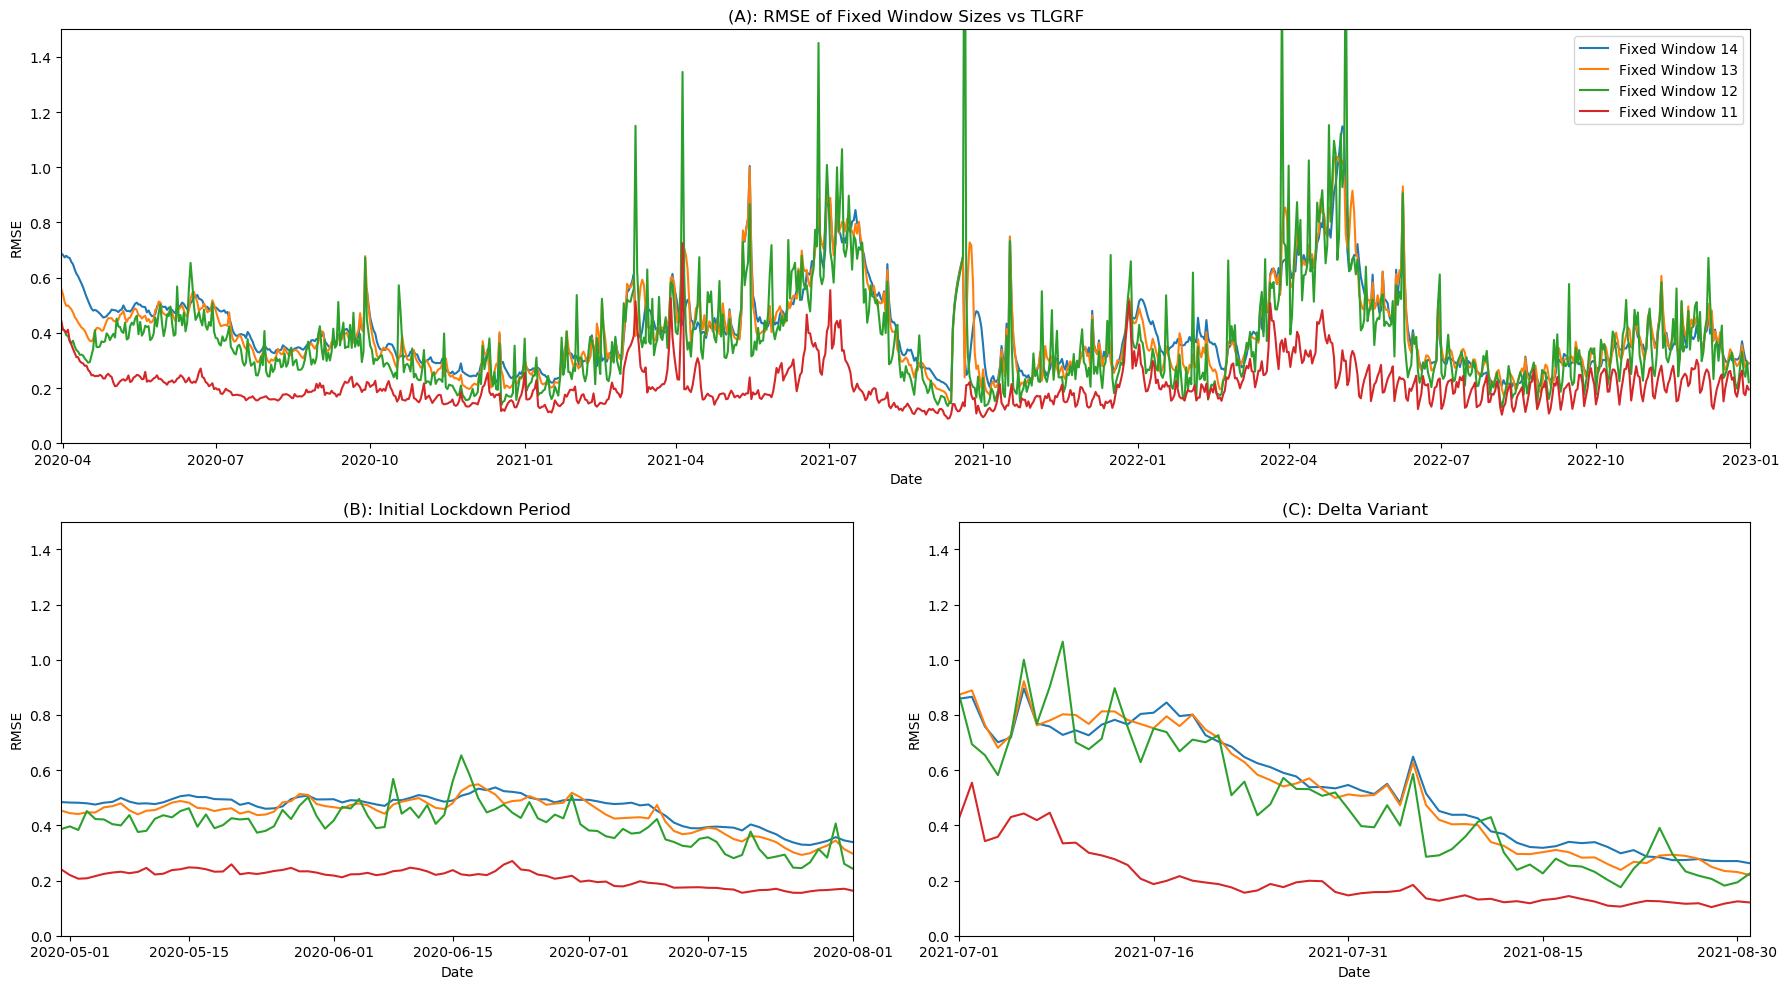

In [22]:
fig = plt.figure(figsize=(18,10))

ax1 = fig.add_subplot(2, 1, 1)
# Create the bottom left subplot
ax2 = fig.add_subplot(2, 2, 3)
# Create the bottom right subplot
ax3 = fig.add_subplot(2, 2, 4)

# Adjust the spacing between subplots
#fig.subplots_adjust(hspace=0.3)

plot_columns =  ["r_TLGRF"] + ["beta_wsize={}".format(window_size) for window_size in [2,7,14]]
plot_columns = reversed(plot_columns)

plot_row_names = list(reversed(row_names))

#plot_columns =  ["r_TLGRF"] + ["beta_wsize={}".format(window_size) for window_size in [2]]
ax1_line_handles = []
for i,plot_column in tqdm(enumerate((plot_columns))):
    ax1_line_handles.append(ax1.plot(RMSE_df[plot_column], label=plot_row_names[i]))
    ax2.plot(RMSE_df[plot_column], label=plot_row_names[i])
    ax3.plot(RMSE_df[plot_column], label=plot_row_names[i])
    
handles = [handle[0] for handle in ax1_line_handles]
labels = [handle[0].get_label() for handle in ax1_line_handles]
locator = mdates.DayLocator(interval=15)
formatter = mdates.DateFormatter('%Y-%m-%d')



ax1.set_xlabel("Date")
ax1.set_ylabel("RMSE")
ax1.set_title("(A): RMSE of Fixed Window Sizes vs TLGRF")
ax1.set_xlim(pd.to_datetime("2020-03-31"), pd.to_datetime("2023-01-01"))
ax1.set_ylim(0,1.5)
ax1.legend(handles, labels, loc='upper right')

ax2.set_xlabel("Date")
ax2.set_ylabel("RMSE")
ax2.set_title("(B): Initial Lockdown Period")
ax2.set_xlim(pd.to_datetime("2020-04-30"), pd.to_datetime("2020-08-01"))
ax2.set_ylim(0,1.5)
#ax2.xaxis.set_major_locator(locator)
#ax2.xaxis.set_major_formatter(formatter)


ax3.set_xlabel("Date")
ax3.set_ylabel("RMSE")
ax3.set_title("(C): Delta Variant")
ax3.set_xlim(pd.to_datetime("2021-07-01"), pd.to_datetime("2021-08-31"))
ax3.set_ylim(0,1.5)
ax3.xaxis.set_major_locator(locator)
ax3.xaxis.set_major_formatter(formatter)


#plt.legend()
#fig.legend(handles, labels, loc='upper ')

# Adjust the layout
plt.tight_layout()
plt.savefig("new_lm_grf_rmse_together.png")

plt.show()

### Save the MAE and RMSE Dataframes

In [23]:
RMSE_df.to_csv("Fixed_windows_RMSE_df.csv")
MAE_df.to_csv("Fixed_windows_MAE_df.csv")


In [24]:
filtered_updated_df.to_csv("Fixed_windows_all_beta.csv", index=False)